# Emotion-vector geometry: Gemma-4-31B (Q1.H1)

Visual companion to `results/emotion_geometry_correlations.json`, mirroring the figures of the
Anthropic emotions paper (transformer-circuits.pub/2026/emotions) on our extracted vectors.

**Data**: 171 per-emotion mean residual-stream vectors x 20 layers (every 3rd of 60), d_model 5376,
extracted 2026-07-21 from 1539 stories (`snae/emotion_stories_gemma_4_4B`), token-weighted means,
TOKEN_OFFSET=50 pooling. Canonical copy: private HF dataset `abotresol/emotion-vectors-gemma-4-31b`;
local bundle `results/emotion_vectors/emotion_means.npz` (gitignored, regenerate from HF or pod).

**Literature anchors**: Anthropic report PC1~valence r=0.81, PC2~arousal r=0.66 (against Russell's
human circumplex ratings, 45 overlapping emotions); the open replication reached r=0.83 with NRC VAD.
We correlate against NRC VAD v2.1 (164/171 emotions matched) — same construct, the replication's instrument.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster import hierarchy
from sklearn.decomposition import PCA

from emotion_vectors.analysis import load_nrc_vad

bundle = np.load("results/emotion_vectors/emotion_means.npz", allow_pickle=True)
emotions, layers, means = list(bundle["emotions"]), list(bundle["layers"]), bundle["means"]
corr = json.loads(Path("results/emotion_geometry_correlations.json").read_text())
vad = load_nrc_vad(Path("data/lexicons/NRC-VAD-Lexicon-v2.1/NRC-VAD-Lexicon-v2.1.txt"))
matched = [i for i, e in enumerate(emotions) if e.lower() in vad]
valence = np.array([vad[emotions[i].lower()][0] for i in matched])
arousal = np.array([vad[emotions[i].lower()][1] for i in matched])
print(f"{means.shape=}, layers {layers[0]}..{layers[-1]}, matched {len(matched)}/{len(emotions)}")

means.shape=(171, 20, 5376), layers 0..57, matched 164/171


## 1. Correlation vs depth

Valence tracking strengthens through the network and plateaus at |r| 0.79-0.83 from layer 30 on
(peak 0.833 at layer 33); arousal is weaker throughout (peak 0.619 at layer 39) — the same ordering
and rough magnitudes the literature reports.

**How to read**: each point is one swept layer (x = depth in the network); height is how strongly
that layer's principal component aligns with the human-rating dimension (|Pearson r|, 1.0 = perfect).
The dashed/dotted horizontal lines are the published values — curves reaching that band = replication.
Blue should sit above orange everywhere (valence is the dominant axis of emotion space).

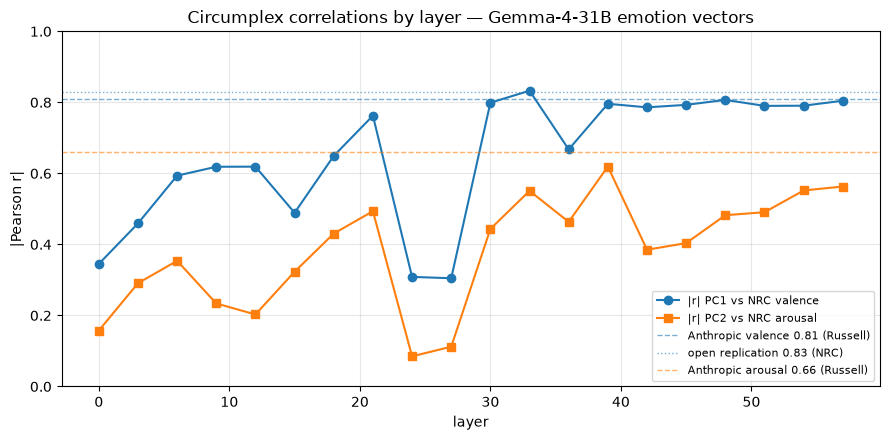

In [2]:
per_layer = corr["per_layer"]
ls = [int(k) for k in per_layer]
r_val = [abs(per_layer[str(l)]["pc1_valence"]["pearson_r"]) for l in ls]
r_aro = [abs(per_layer[str(l)]["pc2_arousal"]["pearson_r"]) for l in ls]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ls, r_val, "o-", label="|r| PC1 vs NRC valence", color="tab:blue")
ax.plot(ls, r_aro, "s-", label="|r| PC2 vs NRC arousal", color="tab:orange")
ax.axhline(0.81, ls="--", lw=1, color="tab:blue", alpha=0.6, label="Anthropic valence 0.81 (Russell)")
ax.axhline(0.83, ls=":", lw=1, color="tab:blue", alpha=0.6, label="open replication 0.83 (NRC)")
ax.axhline(0.66, ls="--", lw=1, color="tab:orange", alpha=0.6, label="Anthropic arousal 0.66 (Russell)")
ax.set_xlabel("layer"); ax.set_ylabel("|Pearson r|"); ax.set_ylim(0, 1)
ax.set_title("Circumplex correlations by layer — Gemma-4-31B emotion vectors")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. The circumplex at the peak layer

PC1/PC2 of the mean-centered vectors at layer 33, colored by NRC valence, sized by arousal
(analog of the paper's Figure 7/8). PC signs are arbitrary; here each PC is oriented so its
target correlation is positive, purely for display.

**How to read**: each dot is one emotion's vector projected onto the top two PCA axes
(x = PC1, y = PC2). If PC1 encodes valence, the colors form a clean left-to-right gradient —
red/negative emotions left, green/positive right. If PC2 encodes arousal, big dots
(high-arousal emotions) drift toward the top and small ones toward the bottom. Labels mark the
most extreme emotions on each axis; a shuffled, gradient-free cloud would mean no circumplex.

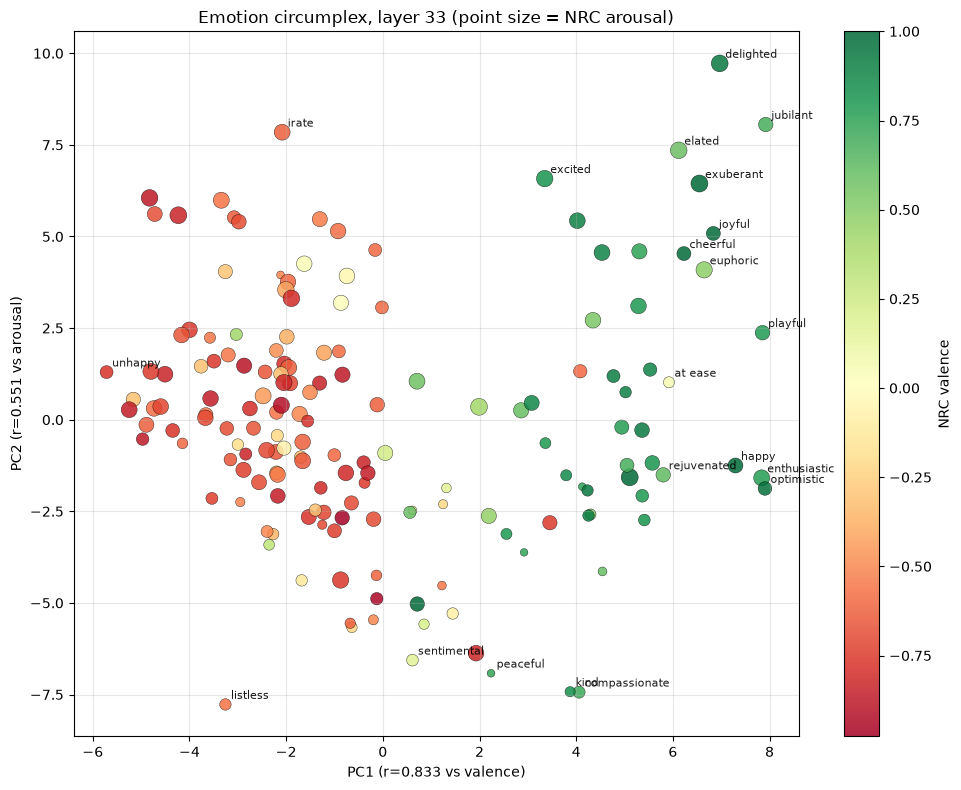

In [3]:
PEAK = layers.index(33)
scores = PCA(n_components=2).fit_transform(means[:, PEAK, :])
pc1, pc2 = scores[matched, 0], scores[matched, 1]
if np.corrcoef(pc1, valence)[0, 1] < 0: pc1, scores[:, 0] = -pc1, -scores[:, 0]
if np.corrcoef(pc2, arousal)[0, 1] < 0: pc2, scores[:, 1] = -pc2, -scores[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(scores[matched, 0], scores[matched, 1], c=valence, cmap="RdYlGn",
                s=30 + 120 * (arousal - arousal.min()) / np.ptp(arousal), alpha=0.85, edgecolors="k", linewidths=0.3)
extremes = np.argsort(np.abs(pc1))[-14:].tolist() + np.argsort(np.abs(pc2))[-10:].tolist()
for j in set(extremes):
    ax.annotate(emotions[matched[j]], (pc1[j], pc2[j]), fontsize=8, alpha=0.9,
                xytext=(4, 4), textcoords="offset points")
plt.colorbar(sc, label="NRC valence")
ax.set_xlabel(f"PC1 (r={np.corrcoef(pc1, valence)[0,1]:.3f} vs valence)")
ax.set_ylabel(f"PC2 (r={np.corrcoef(pc2, arousal)[0,1]:.3f} vs arousal)")
ax.set_title("Emotion circumplex, layer 33 (point size = NRC arousal)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Pairwise cosine similarity, hierarchically clustered

Analog of the paper's Figure 5: synonym-like emotions should form bright blocks, opposite-valence
emotions should be negative. Vectors are mean-centered before cosine (difference-of-means contrasts).

**How to read**: rows and columns are the 171 emotions, reordered so similar vectors sit next to
each other (hierarchical clustering; every 5th label shown). Red blocks along the diagonal are
clusters of near-synonymous emotions; blue regions are pairs pointing in opposite directions
(typically opposite valence). A structureless gray field would mean the vectors carry no shared
emotional geometry.

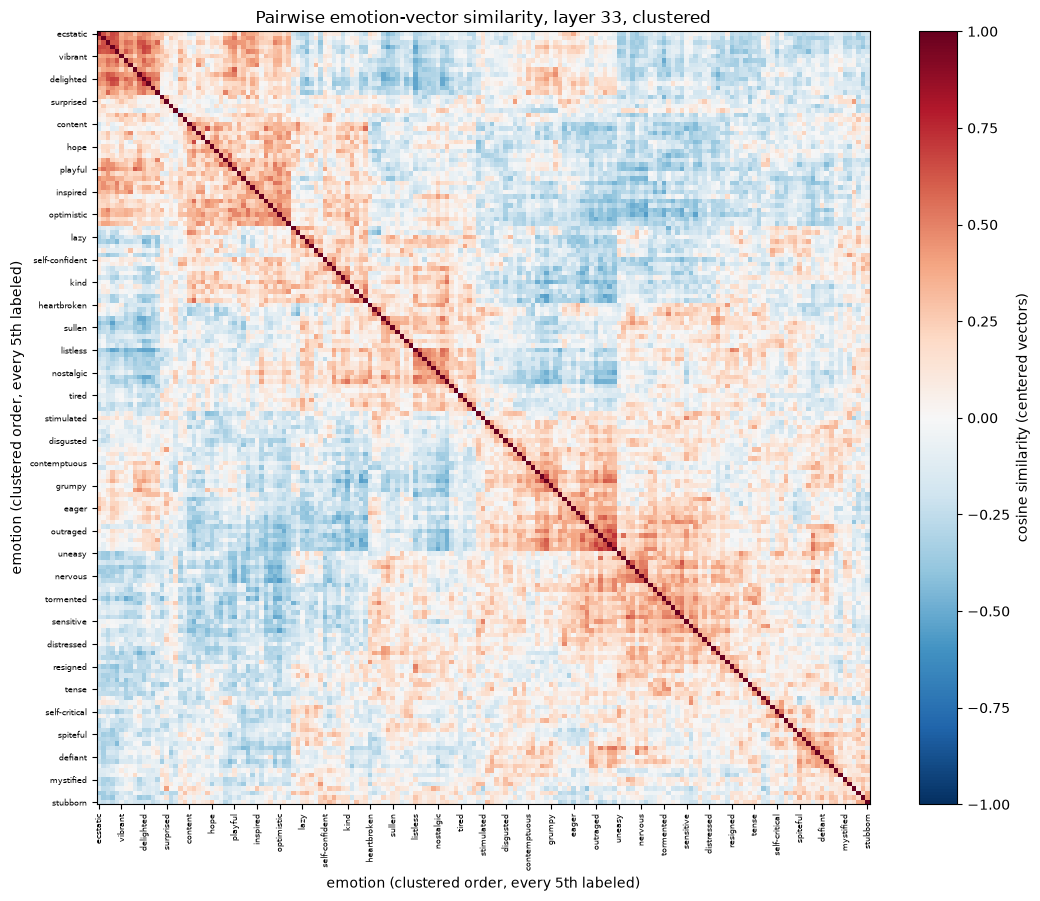

first cluster block: [np.str_('ecstatic'), np.str_('euphoric'), np.str_('joyful'), np.str_('elated'), np.str_('exuberant'), np.str_('vibrant'), np.str_('cheerful'), np.str_('thrilled')]


In [4]:
def centered_cosine(layer_means):
    c = layer_means - layer_means.mean(axis=0, keepdims=True)
    n = c / np.linalg.norm(c, axis=1, keepdims=True)
    return n @ n.T

sim = centered_cosine(means[:, PEAK, :])
order = hierarchy.leaves_list(hierarchy.linkage(1 - sim, method="average"))

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(sim[np.ix_(order, order)], cmap="RdBu_r", vmin=-1, vmax=1)
ticks = range(0, len(order), 5)
ax.set_xticks(list(ticks)); ax.set_xticklabels([emotions[order[t]] for t in ticks], rotation=90, fontsize=6)
ax.set_yticks(list(ticks)); ax.set_yticklabels([emotions[order[t]] for t in ticks], fontsize=6)
plt.colorbar(im, label="cosine similarity (centered vectors)")
ax.set_xlabel("emotion (clustered order, every 5th labeled)")
ax.set_ylabel("emotion (clustered order, every 5th labeled)")
ax.set_title("Pairwise emotion-vector similarity, layer 33, clustered")
plt.tight_layout(); plt.show()

block = [emotions[i] for i in order[:8]]
print("first cluster block:", block)

## 4. Representational stability across layers

Analog of the paper's Figure 9: per layer, compute the pairwise-similarity matrix, then correlate
the (upper-triangle) similarity structure between layers. The paper reports high stability from
early-middle to late layers.

**How to read**: cell (i, j) asks "do layers i and j agree on which emotions are similar to
which?" — 1.0 (bright yellow) means the two layers' emotion geometries are relationally identical,
0 (dark) means unrelated. A large bright block covering the middle-to-late layers means the
geometry consolidates early and stays stable — which is what licenses analysing at a single
mid-late layer, as the paper does.

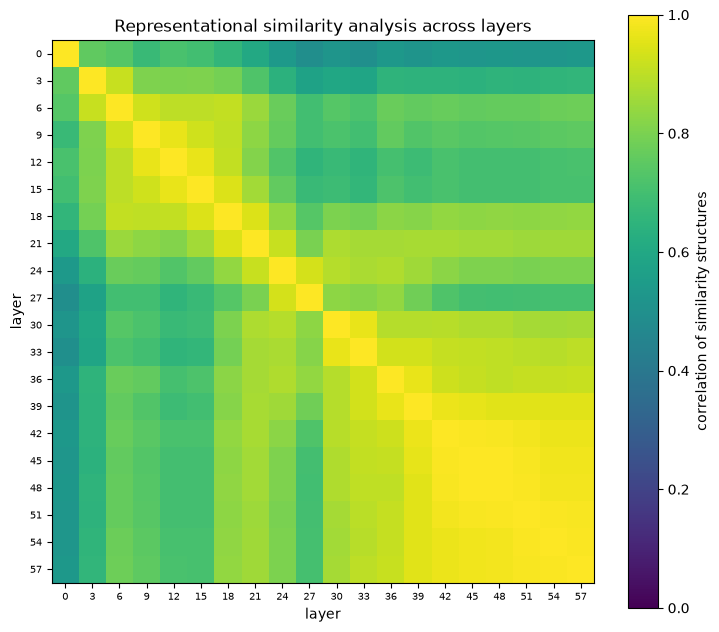

mean RSA within layers 30-57: 0.939
mean RSA layer 0 vs layers 30-57: 0.524


In [5]:
iu = np.triu_indices(len(emotions), k=1)
flat = np.stack([centered_cosine(means[:, p, :])[iu] for p in range(len(layers))])
rsa = np.corrcoef(flat)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(rsa, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(layers))); ax.set_xticklabels(layers, fontsize=7)
ax.set_yticks(range(len(layers))); ax.set_yticklabels(layers, fontsize=7)
plt.colorbar(im, label="correlation of similarity structures")
ax.set_xlabel("layer"); ax.set_ylabel("layer")
ax.set_title("Representational similarity analysis across layers")
plt.tight_layout(); plt.show()

mid = [p for p, l in enumerate(layers) if 30 <= l <= 57]
print(f"mean RSA within layers 30-57: {rsa[np.ix_(mid, mid)][np.triu_indices(len(mid), k=1)].mean():.3f}")
print(f"mean RSA layer 0 vs layers 30-57: {rsa[0, mid].mean():.3f}")

## Reading

- **Depth profile** matches the literature's story: circumplex structure consolidates by the middle
  of the network and stays put (valence plateau |r| 0.79-0.83, layers 30-57).
- **Valence >> arousal**, as both the Anthropic paper and the open replication report.
- The **clustered similarity matrix** shows the expected synonym blocks and cross-valence
  anti-correlation, and the **RSA** shows the paper's early-middle-to-late stability.
- Caveats live in TREE.md (Q1.H1.C1, [unvalidated]): the falsify gate — permutation null,
  bootstrap CI, and the Pearson-vs-Spearman gap — runs before any of this graduates to a claim.